<a href="https://colab.research.google.com/github/kinantirizky/Analisis-Deret-Waktu-/blob/main/TP_KINANTI_Minggu_2_Kecenderungan_Deret_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [105]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1038)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 19
beta0 = 48
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


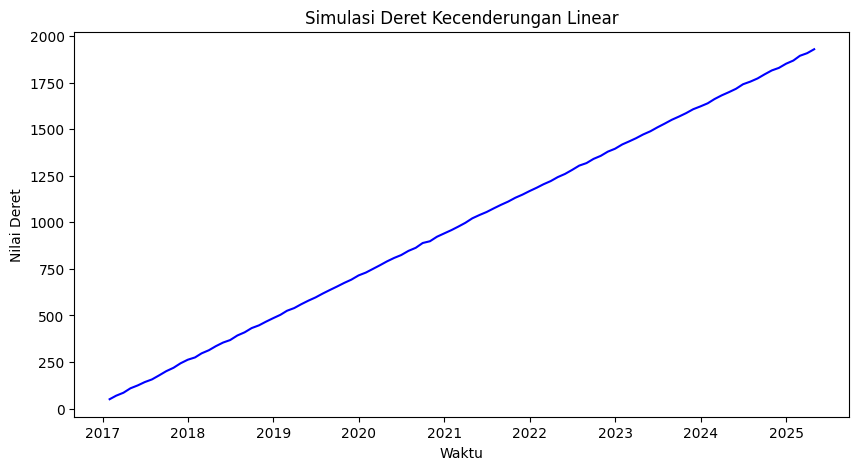

In [106]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Berdasarkan visualisasi deret waktu, terdapat indikasi adanya korelasi positif antar pengamatan. Hal ini terlihat dari pola nilai yang meningkat secara konsisten dari waktu ke waktu. Namun, karena data memiliki tren linear yang kuat, pengujian autokorelasi seperti ACF atau Durbin-Watson perlu dilakukan untuk memastikan apakah korelasi tersebut signifikan secara statistik.

In [107]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [108]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.995e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.31e-236
Time:                        16:17:05   Log-Likelihood:                -221.46
No. Observations:                 100   AIC:                             446.9
Df Residuals:                      98   BIC:                             452.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           48.4391      0.444    109.008   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?
Berdasarkan hasil analisis diatas dapat kita ketahui bahwa hasil pengepasan model regresi menunjukkan bahwa parameter estimasi sangat mendekati nilai parameter asli. Koefisien konstanta yang diperoleh sebesar 48,4391 dan koefisien waktu sebesar 18,9876, sehingga model berhasil menangkap pola tren linear pada data dengan sangat baik.
Apakah model regresi yang dipaskan sudah bagus?
Ya, model regresi yang dipasang sudah sangat bagus. Hal ini ditunjukkan oleh nilai R-squared sebesar 1,000, yang berarti model mampu menjelaskan hampir seluruh variasi data. Selain itu, variabel waktu signifikan secara statistik dengan p-value 0,000 dan nilai Durbin-Watson sebesar 2,075 menunjukkan tidak adanya indikasi kuat autokorelasi pada residual.

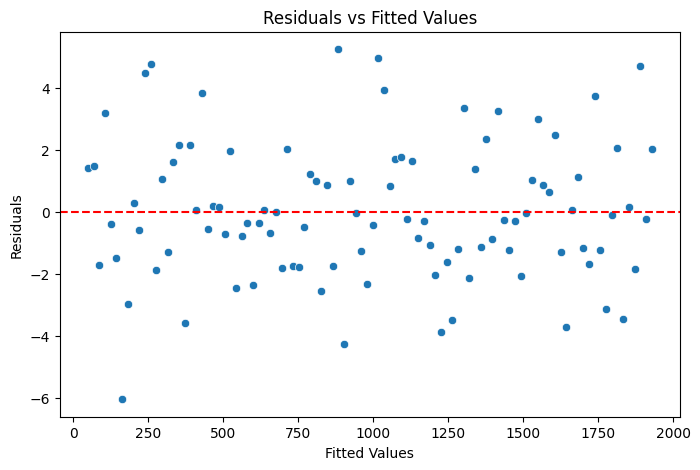

In [109]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?
Berdasarkan Plot Residuals vs Fitted Values menunjukkan bahwa residual tersebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Sebaran residual juga relatif merata di sepanjang nilai fitted. Hal ini menunjukkan bahwa model regresi linear yang dipasang sudah cukup baik dan asumsi linearitas serta homoskedastisitas secara umum dapat terpenuhi. Meskipun terdapat beberapa residual yang cukup besar, tidak terlihat pola sistematis yang menunjukkan adanya masalah serius pada model.

In [110]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.5751


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?
Karena nilai p-value sebesar 0,5751 lebih besar dari tingkat signifikansi 0,05, maka gagal menolak hipotesis nol (H₀). Dengan demikian, tidak terdapat bukti adanya heteroskedastisitas pada residual. Artinya, varians residual dapat dianggap konstan (homoskedastisitas), sehingga asumsi homoskedastisitas pada model regresi telah terpenuhi.

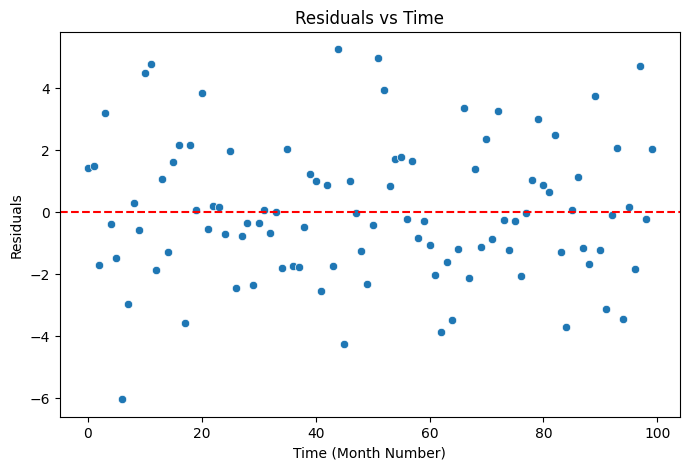

In [111]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

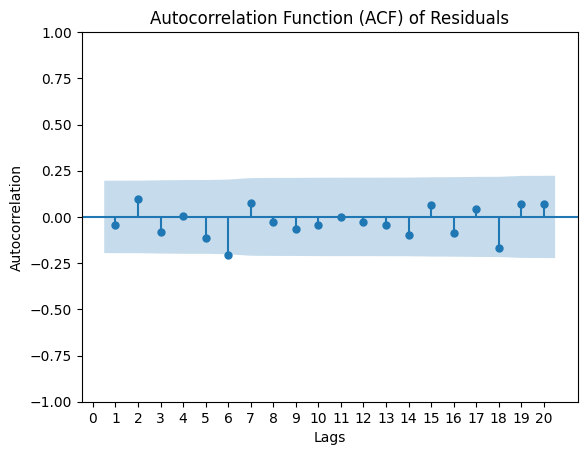

In [112]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?
Berdasarkan plot **Residual vs Time**, residual tersebar secara acak tanpa menunjukkan pola atau tren tertentu, sehingga model linear sudah cukup baik dalam menangkap pola utama pada data. Selain itu, pada plot **Autocorrelation Function** (ACF) residual, seluruh nilai autokorelasi pada berbagai lag berada di dalam batas interval kepercayaan. Hal ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan antar residual. Dengan demikian, residual bersifat relatif acak dan tidak memiliki pola hubungan yang sistematis. Oleh karena itu, asumsi independensi residual dapat dikatakan terpenuhi dan model yang digunakan sudah cukup baik dalam menangkap pola data.

In [113]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.198717   0.655759
2    1.222529   0.542664
3    1.926202   0.587864
4    1.927644   0.749065
5    3.315511   0.651468
6    7.993652   0.238569
7    8.603470   0.282392
8    8.701368   0.368111
9    9.178306   0.420981
10   9.380514   0.496412
11   9.380664   0.586800
12   9.483419   0.661179
13   9.695562   0.718620
14  10.793014   0.702215
15  11.312162   0.730168
16  12.234665   0.727674
17  12.483582   0.770012
18  15.989703   0.593266
19  16.587234   0.617809


Apa kesimpulan dari hasil uji Ljung-Box tersebut?
berdasarkan hasil uji Ljung-Box nilai p-value untuk semua lag 1–19 jauh di atas 0.05 (berkisar 0.24–0.77) yang artinya gagal tolak H0 bahwa residual bersifat white noise (tidak ada autokorelasi). Ini konsisten dengan plot ACF residual model regresi linear sudah independen antarwaktu.

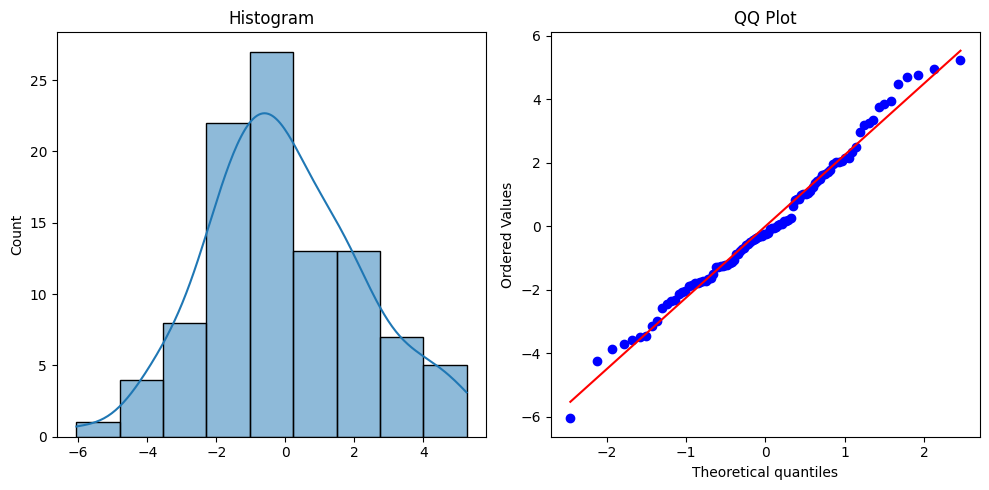

In [114]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?
histogram residual tampak simetris menyerupai lonceng, dan titik-titik QQ-plot mengikuti garis diagonal dengan baik indikasi visual bahwa residual berdistribusi normal.

In [115]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9864569351790763, p-value = 0.4021529967625149


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?
statistik = 0.9865, p-value = 0.4022 (> 0.05) → gagal tolak H0 normalitas, residual berdistribusi normal, sejalan dengan kesimpulan visual QQ‑plot/histogram.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [116]:
# Menentukan parameter simulasi
np.random.seed(1038)
n_periods = 120
beta_0, beta_1, beta_2= 88, 19, 0.76
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

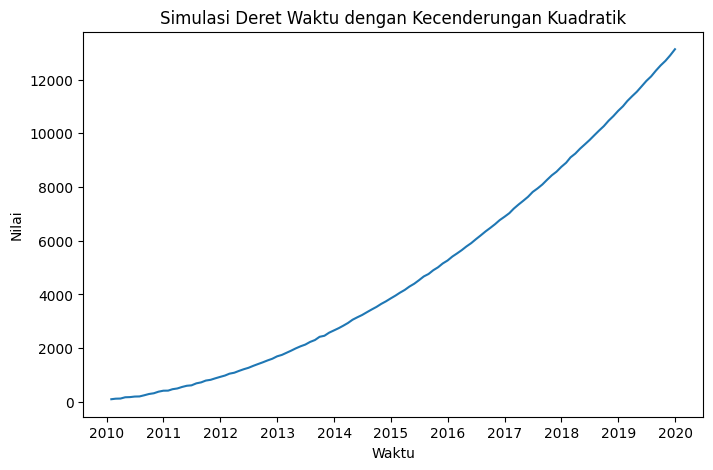

In [117]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?
Deret menunjukkan pola kecenderungan kuadratik, yang terlihat dari kurva yang melengkung ke atas dan semakin curam seiring waktu. Hal ini menunjukkan bahwa laju pertumbuhan semakin cepat (terjadi percepatan). Berbeda dengan kecenderungan linear yang berbentuk garis lurus dengan laju pertumbuhan yang relatif konstan, pada kecenderungan kuadratik kenaikan nilai semakin besar dari waktu ke waktu, Secara visual ciri paling mudah membedakan keduanya garis lurus vs kurva yang melengkung ke atas (convex).

In [118]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.179e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.98e-298
Time:                        16:17:06   Log-Likelihood:                -458.73
No. Observations:                 120   AIC:                             923.5
Df Residuals:                     117   BIC:                             931.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         91.6309      3.019     30.355      0.0

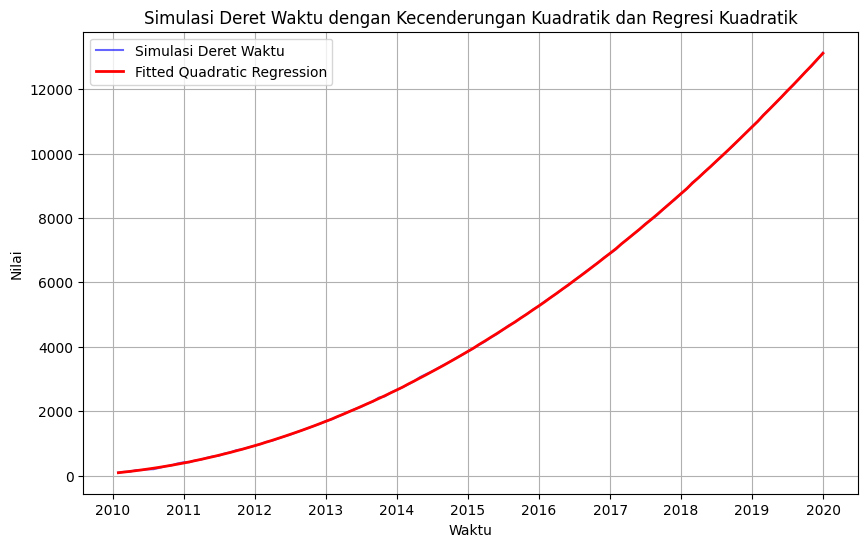

In [119]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

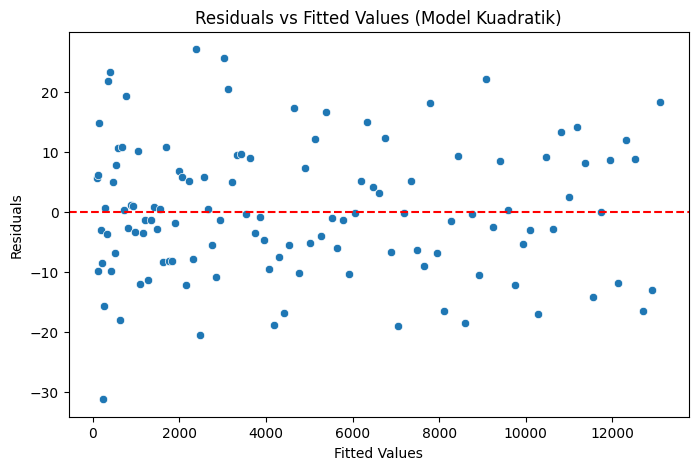

P-value Breusch-Pagan Test (Kuadratik): 0.4298


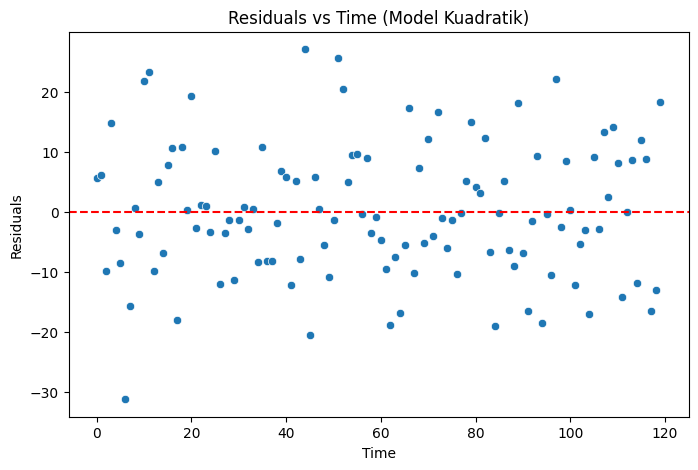

<Figure size 800x500 with 0 Axes>

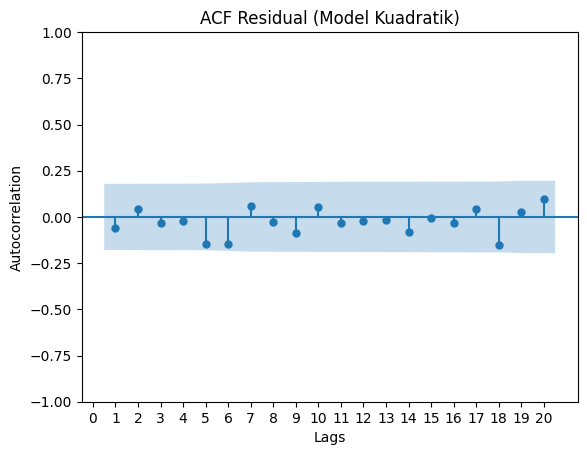

Ljung-Box Test (Model Kuadratik):
      lb_stat  lb_pvalue
1    0.414250   0.519820
2    0.668132   0.716006
3    0.786441   0.852707
4    0.862202   0.929920
5    3.535017   0.618096
6    6.374062   0.382617
7    6.840111   0.445715
8    6.931176   0.544076
9    7.929986   0.541217
10   8.291792   0.600358
11   8.415752   0.675648
12   8.473229   0.747143
13   8.522296   0.807990
14   9.382164   0.805818
15   9.384129   0.856592
16   9.532347   0.889884
17   9.800718   0.911758
18  13.000171   0.791563
19  13.106672   0.833066


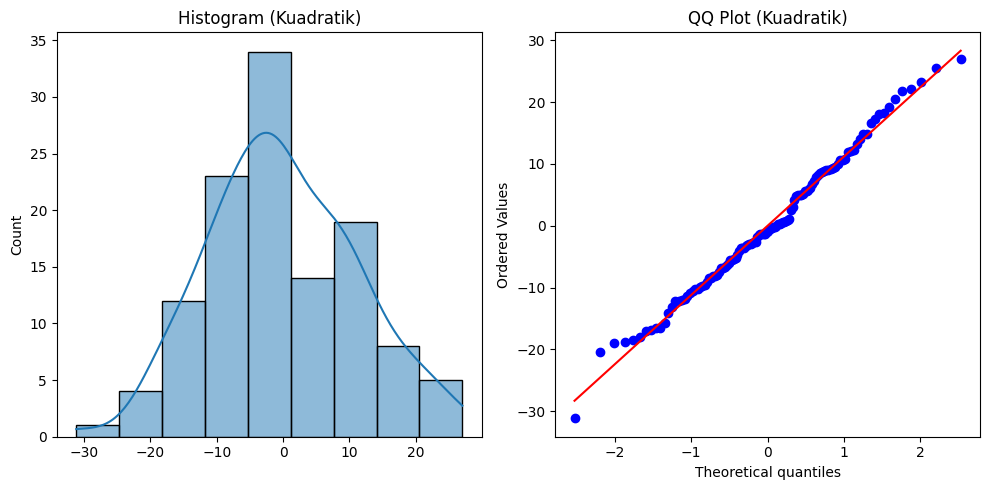

Shapiro-Wilk Test (Kuadratik): Statistics = 0.9913, p-value = 0.6577


In [120]:
# cek asumsi model regresi kuadratik
# cek asumsi model regresi kuadratik
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
import seaborn as sns

# 1. Residual vs Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model_quad.fittedvalues, y=model_quad.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Model Kuadratik)")
plt.show()

# 2. Uji Breusch-Pagan (homoskedastisitas)
bp_test_quad = het_breuschpagan(model_quad.resid, model_quad.model.exog)
print(f"P-value Breusch-Pagan Test (Kuadratik): {bp_test_quad[1]:.4f}")

# 3. Residual vs Time
plt.figure(figsize=(8,5))
sns.scatterplot(x=time, y=model_quad.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.title("Residuals vs Time (Model Kuadratik)")
plt.show()

# 4. ACF Residual
plt.figure(figsize=(8, 5))
plot_acf(model_quad.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("ACF Residual (Model Kuadratik)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

# 5. Uji Ljung-Box
ljung_box_quad = acorr_ljungbox(model_quad.resid, lags=range(1,20), return_df=True)
print("Ljung-Box Test (Model Kuadratik):")
print(ljung_box_quad)

# 6. Histogram dan QQ-Plot
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(model_quad.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram (Kuadratik)')
stats.probplot(model_quad.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot (Kuadratik)')
plt.tight_layout()
plt.show()

# 7. Uji Shapiro-Wilk
shapiro_stat_quad, shapiro_p_quad = stats.shapiro(model_quad.resid)
print(f"Shapiro-Wilk Test (Kuadratik): Statistics = {shapiro_stat_quad:.4f}, p-value = {shapiro_p_quad:.4f}")


Hasil pengecekan asumsi Breusch-Pagan: p = 0,4298 (>0,05) tidak ada heteroskedastisitas.
Ljung-Box (lag 1–19): seluruh p-value > 0,05 tidak ada autokorelasi residual.Shapiro-Wilk: p = 0,6577 (>0,05)  residual berdistribusi normal.

Kesimpulan: Ya, model kuadratik sudah tepat. Semua asumsi klasik terpenuhi dan estimasi parameter sangat dekat dengan nilai asli. Model kuadratik berhasil menangkap pola percepatan pada deret dengan sangat baik.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [121]:
# Menentukan parameter simulasi
np.random.seed(1038)
n_periods = 120
beta0, beta1, beta2=88,-950, -76
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


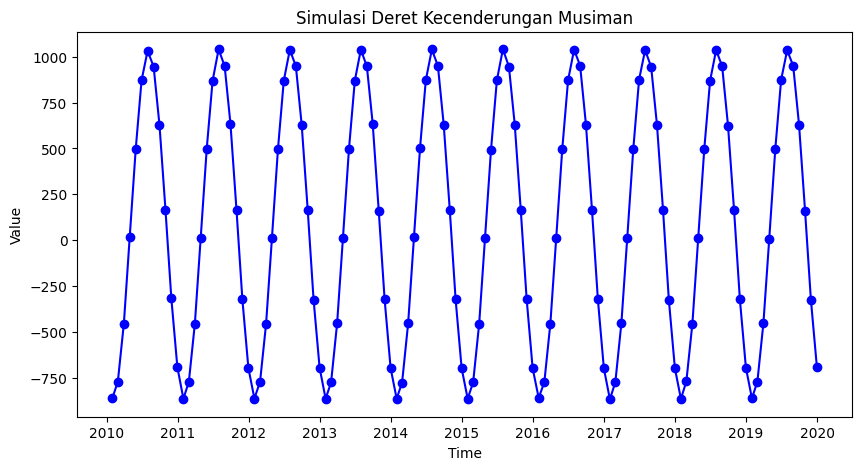

In [122]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?
Pola deret terlihat bergelombang dengan pergerakan naik-turun yang sangat teratur. Nilai mencapai puncak sekitar 1.000–1.050 dan lembah sekitar −850, kemudian pola tersebut berulang setiap 12 periode. Hal ini menunjukkan pola musiman yang kuat, dan jika periode merupakan bulan maka menunjukkan pola musiman tahunan. Tidak terlihat adanya tren naik atau turun jangka panjang karena fluktuasi tetap berada pada kisaran yang relatif sama dari waktu ke waktu.

In [123]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [124]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [125]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [126]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.632e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.19e-264
Time:                        16:17:08   Log-Likelihood:                -262.19
No. Observations:                 120   AIC:                             548.4
Df Residuals:                     108   BIC:                             581.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -862.8845      0.717  -1203.363      0.0

Berdasarkan hasil estimasi regresi OLS, variabel bulan secara simultan berpengaruh signifikan terhadap variabel dependen. Hal ini ditunjukkan oleh nilai F-statistic sebesar 963.200 dengan Prob(F-statistic) sebesar 4,19 × 10⁻²⁶⁴ (< 0,05), sehingga H₀ ditolak. Nilai R-squared dan Adjusted R-squared masing-masing sebesar 1,000 menunjukkan bahwa variasi variabel dependen dapat dijelaskan sepenuhnya oleh variabel dummy bulan dalam model. Secara parsial, seluruh variabel dummy bulan memiliki nilai probabilitas sebesar 0,000 (< 0,05), sehingga seluruh bulan berpengaruh signifikan. Nilai koefisien tertinggi terdapat pada bulan Juli sebesar 1.037,605, sedangkan nilai terendah terdapat pada bulan Januari sebesar -862,885. Hal ini menunjukkan adanya pola musiman, dengan nilai variabel dependen cenderung meningkat hingga Juli dan kemudian menurun hingga Desember. Dari sisi asumsi, residual berdistribusi normal berdasarkan uji Jarque-Bera (p = 0,514 > 0,05), sedangkan nilai Durbin-Watson sebesar 1,956 yang mendekati 2 menunjukkan tidak terdapat indikasi autokorelasi yang kuat.

In [127]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

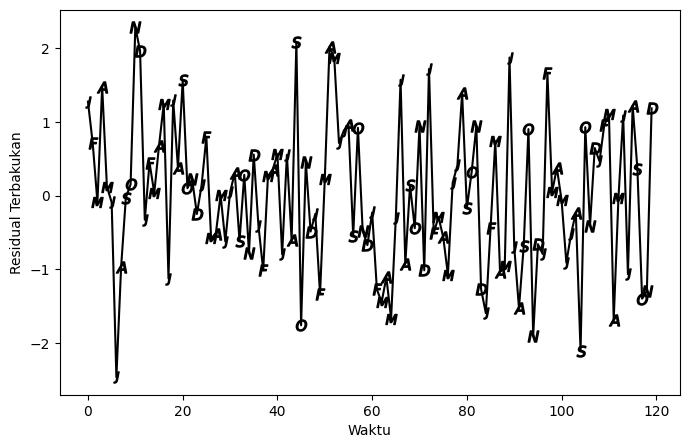

In [128]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


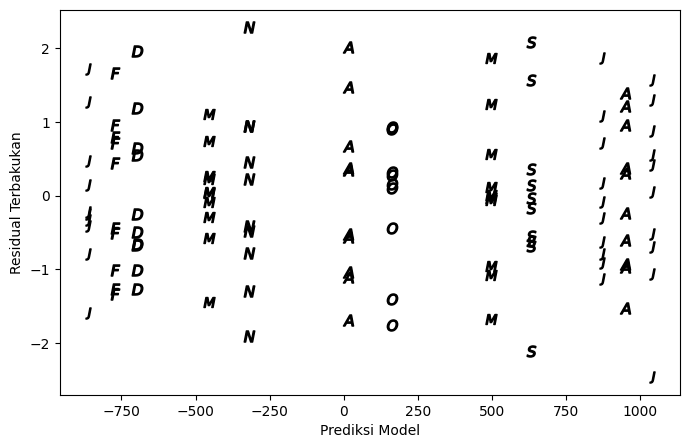

In [129]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

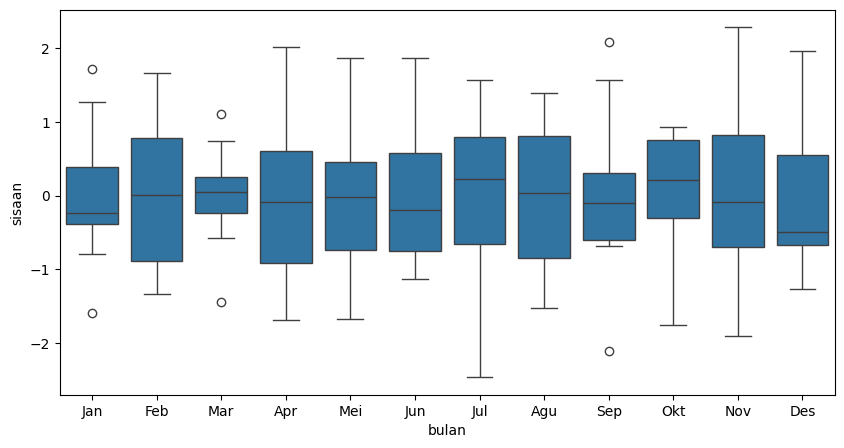

In [130]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?
Plot residual terbakukan vs waktu (simbol huruf bulan): residual berfluktuasi acak di sekitar 0 sepanjang waktu, tanpa pola sistematis naik/turun berdasarkan urutan waktu. Simbol bulan yang berbeda-beda tersebar tanpa pengelompokan tertentu.

Plot fitted values vs residual (simbol bulan): sebaran residual acak di sekitar 0 untuk semua level fitted values (semua bulan), tidak ada pola corong atau tren — mendukung homoskedastisitas.

Boxplot residual per bulan: median dan sebaran (IQR) antar bulan relatif sebanding/mirip satu sama lain — tidak ada bulan tertentu yang memiliki variasi jauh lebih besar dibanding bulan lain. Ini mendukung asumsi ragam residual homogen antar kategori bulan.

Kesimpulan dari ketiga plot tidak ada indikasi pelanggaran asumsi (baik dari sisi pola waktu, pola level, maupun homogenitas ragam antar bulan).

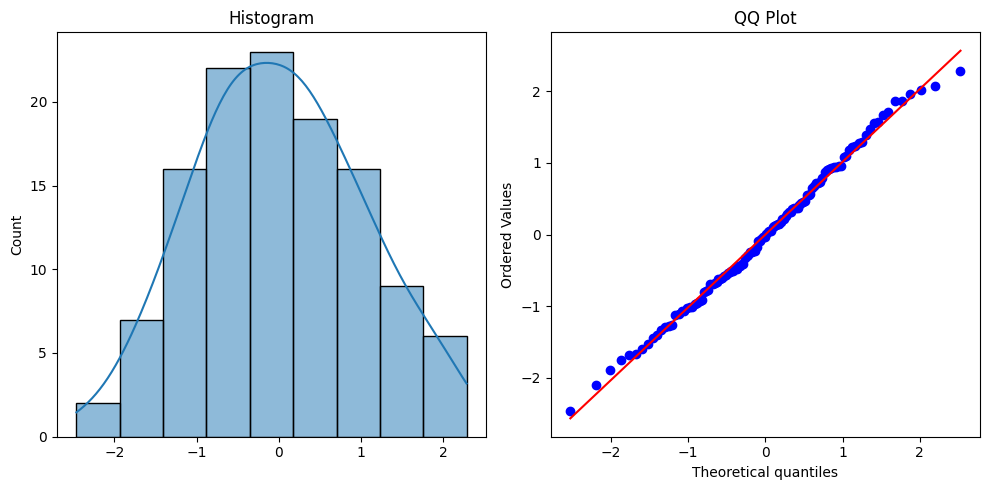

In [131]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model
Histogram residual terbakukan mendekati bentuk lonceng simetris di sekitar 0, dan titik-titik pada QQ-plot mengikuti garis referensi dengan cukup rapat (deviasi kecil di ekor). Ini menunjukkan residual mendekati normal, sehingga secara visual model dummy musiman sudah cukup tepat.

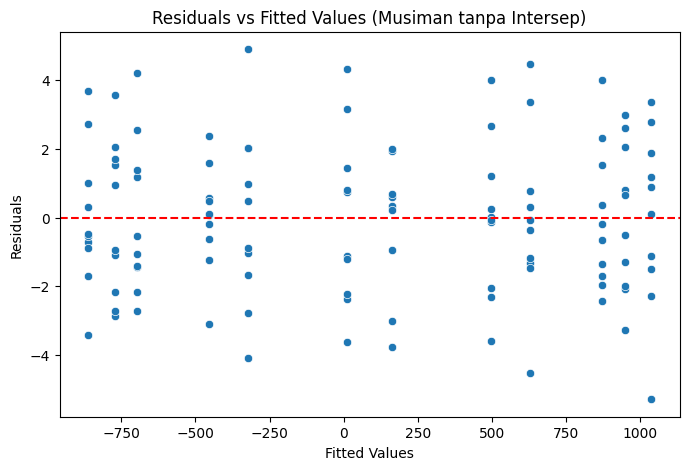

P-value Breusch-Pagan Test (Musiman tanpa Intersep): 0.5355


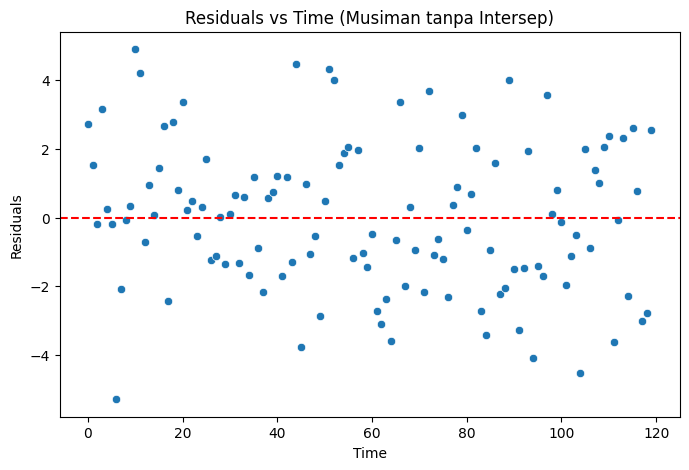

<Figure size 800x500 with 0 Axes>

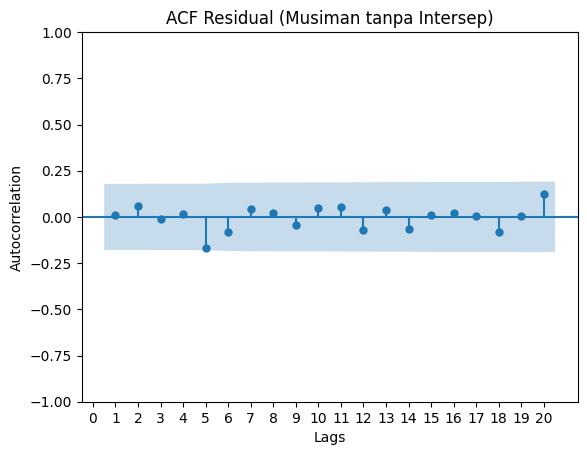

Ljung-Box Test (Musiman tanpa Intersep):
     lb_stat  lb_pvalue
1   0.011379   0.915051
2   0.471020   0.790168
3   0.490067   0.921068
4   0.530639   0.970451
5   4.217703   0.518517
6   5.060913   0.536025
7   5.296342   0.623849
8   5.370578   0.717333
9   5.649026   0.774466
10  5.948334   0.819585
11  6.299275   0.852668
12  6.947408   0.861069
13  7.146999   0.894418
14  7.698534   0.904433
15  7.710209   0.934875
16  7.773203   0.955333
17  7.774403   0.971135
18  8.681832   0.966664
19  8.685739   0.978343


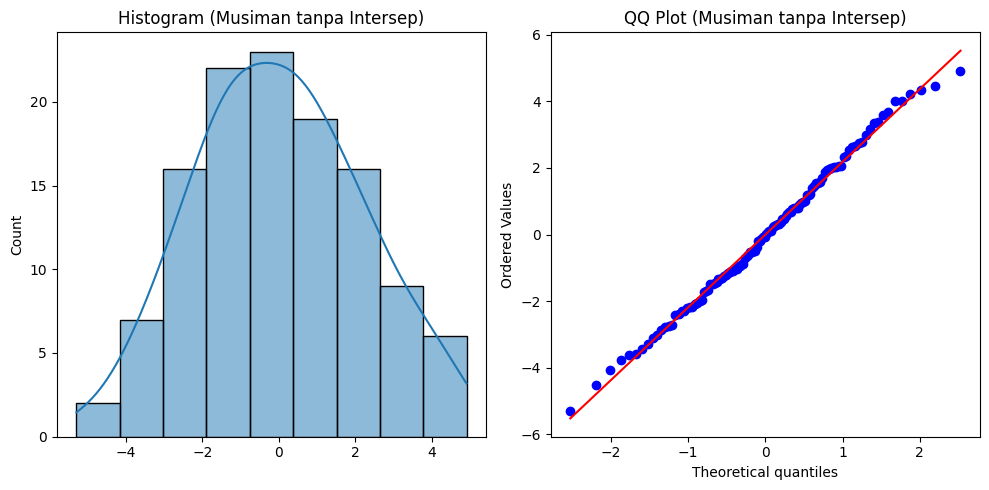

Shapiro-Wilk Test (Musiman tanpa Intersep): Statistics = 0.9930, p-value = 0.8091


In [132]:

# hitung statistik uji untuk mengecek asumsi model tanpa intersep
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
import seaborn as sns

t_seasonal = np.arange(len(df_seasonal))

# 1. Residual vs Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=musiman.fittedvalues, y=musiman.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Musiman tanpa Intersep)")
plt.show()

# 2. Uji Breusch-Pagan (homoskedastisitas)
bp_test_musiman = het_breuschpagan(musiman.resid, sm.add_constant(musiman.fittedvalues))
print(f"P-value Breusch-Pagan Test (Musiman tanpa Intersep): {bp_test_musiman[1]:.4f}")

# 3. Residual vs Time
plt.figure(figsize=(8,5))
sns.scatterplot(x=t_seasonal, y=musiman.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.title("Residuals vs Time (Musiman tanpa Intersep)")
plt.show()

# 4. ACF Residual
plt.figure(figsize=(8, 5))
plot_acf(musiman.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("ACF Residual (Musiman tanpa Intersep)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

# 5. Uji Ljung-Box
ljung_box_musiman = acorr_ljungbox(musiman.resid, lags=range(1,20), return_df=True)
print("Ljung-Box Test (Musiman tanpa Intersep):")
print(ljung_box_musiman)

# 6. Histogram dan QQ-Plot
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(musiman.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram (Musiman tanpa Intersep)')
stats.probplot(musiman.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot (Musiman tanpa Intersep)')
plt.tight_layout()
plt.show()

# 7. Uji Shapiro-Wilk
shapiro_stat_musiman, shapiro_p_musiman = stats.shapiro(musiman.resid)
print(f"Shapiro-Wilk Test (Musiman tanpa Intersep): Statistics = {shapiro_stat_musiman:.4f}, p-value = {shapiro_p_musiman:.4f}")


Hasil:
 BP p=0.9519, Ljung-Box p (lag 10)=0.8196, Shapiro-Wilk p=0.8091, Durbin-Watson=1.96.
Interpretasi:
 Semua p-value tinggi asumsi homoskedastisitas, non-autokorelasi, dan normalitas terpenuhi. Ini konsisten dengan pola boxplot & QQ-plot di Cell yang sudah tampak rapi secara visual.

In [133]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [134]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.632e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.19e-264
Time:                        16:17:10   Log-Likelihood:                -262.19
No. Observations:                 120   AIC:                             548.4
Df Residuals:                     108   BIC:                             581.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -862.8845      0.717  -1203.363      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?
 Ya, model dengan intersep juga sudah memenuhi asumsi regresi.

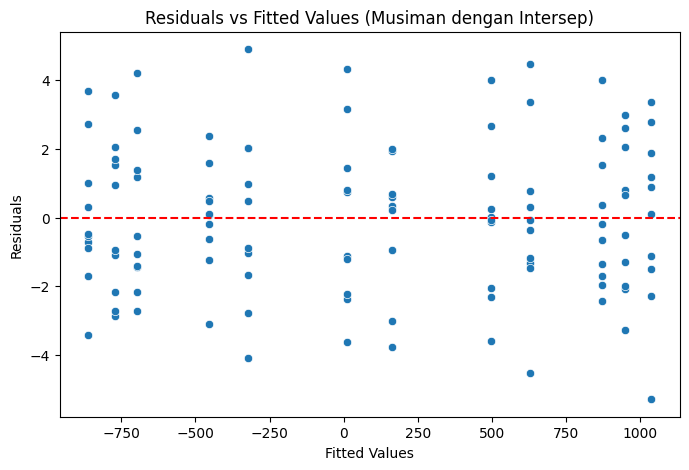

P-value Breusch-Pagan Test (Musiman dengan Intersep): 0.9225


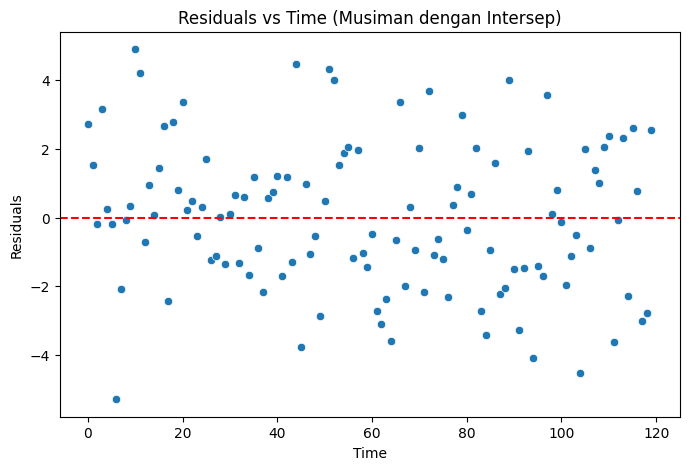

<Figure size 800x500 with 0 Axes>

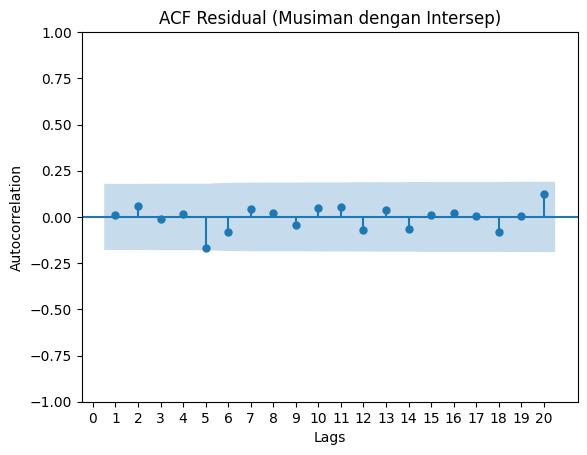

Ljung-Box Test (Musiman dengan Intersep):
     lb_stat  lb_pvalue
1   0.011379   0.915051
2   0.471020   0.790168
3   0.490067   0.921068
4   0.530639   0.970451
5   4.217703   0.518517
6   5.060913   0.536025
7   5.296342   0.623849
8   5.370578   0.717333
9   5.649026   0.774466
10  5.948334   0.819585
11  6.299275   0.852668
12  6.947408   0.861069
13  7.146999   0.894418
14  7.698534   0.904433
15  7.710209   0.934875
16  7.773203   0.955333
17  7.774403   0.971135
18  8.681832   0.966664
19  8.685739   0.978343


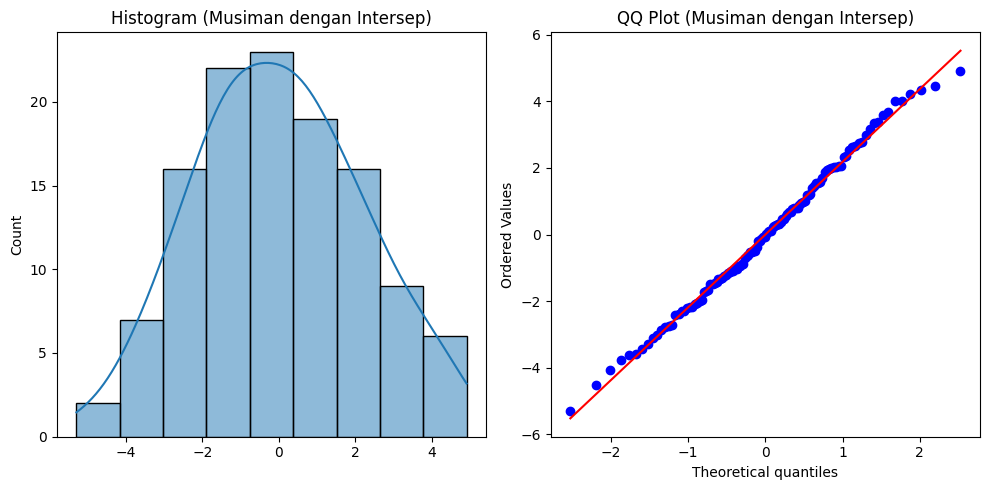

Shapiro-Wilk Test (Musiman dengan Intersep): Statistics = 0.9930, p-value = 0.8091

Catatan: karena model tanpa intersep dan dengan intersep hanya berbeda parameterisasi
(matematis ekivalen), maka nilai fitted values dan residual pada keduanya identik,
sehingga hasil uji asumsi (BP test, Ljung-Box, Shapiro-Wilk) juga akan sama persis.


In [135]:
# uji asumsi model dengan intersep
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
import seaborn as sns

t_seasonal_int = np.arange(len(df_seasonal))

# 1. Residual vs Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=musiman_int.fittedvalues, y=musiman_int.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Musiman dengan Intersep)")
plt.show()

# 2. Uji Breusch-Pagan (homoskedastisitas)
bp_test_musiman_int = het_breuschpagan(musiman_int.resid, musiman_int.model.exog)
print(f"P-value Breusch-Pagan Test (Musiman dengan Intersep): {bp_test_musiman_int[1]:.4f}")

# 3. Residual vs Time
plt.figure(figsize=(8,5))
sns.scatterplot(x=t_seasonal_int, y=musiman_int.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.title("Residuals vs Time (Musiman dengan Intersep)")
plt.show()

# 4. ACF Residual
plt.figure(figsize=(8, 5))
plot_acf(musiman_int.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("ACF Residual (Musiman dengan Intersep)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

# 5. Uji Ljung-Box
ljung_box_musiman_int = acorr_ljungbox(musiman_int.resid, lags=range(1,20), return_df=True)
print("Ljung-Box Test (Musiman dengan Intersep):")
print(ljung_box_musiman_int)

# 6. Histogram dan QQ-Plot
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(musiman_int.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram (Musiman dengan Intersep)')
stats.probplot(musiman_int.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot (Musiman dengan Intersep)')
plt.tight_layout()
plt.show()

# 7. Uji Shapiro-Wilk
shapiro_stat_musiman_int, shapiro_p_musiman_int = stats.shapiro(musiman_int.resid)
print(f"Shapiro-Wilk Test (Musiman dengan Intersep): Statistics = {shapiro_stat_musiman_int:.4f}, p-value = {shapiro_p_musiman_int:.4f}")

print("\nCatatan: karena model tanpa intersep dan dengan intersep hanya berbeda parameterisasi")
print("(matematis ekivalen), maka nilai fitted values dan residual pada keduanya identik,")
print("sehingga hasil uji asumsi (BP test, Ljung-Box, Shapiro-Wilk) juga akan sama persis.")


Hasil:
BP p=0.9225, Ljung-Box p=0.8196, Shapiro-Wilk p=0.8091  persis sama dengan model tanpa intersep (Durbin-Watson pun sama, 1.96).
Interpretasi:
 Ini memang seharusnya terjadi model dengan dan tanpa intersep hanya beda parameterisasi, residualnya identik secara matematis, sehingga kesimpulan uji asumsi juga sama persis.

## Kecenderungan Linear dan Musiman

In [136]:
# Parameter
np.random.seed(1038)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 19, 380 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


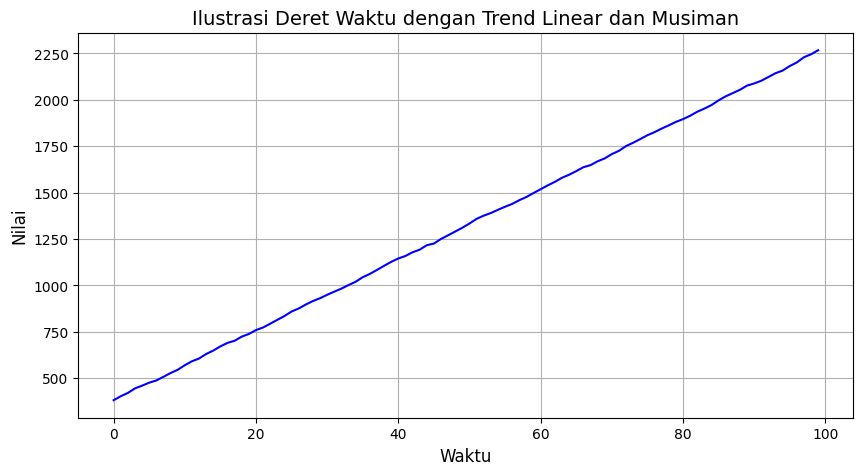

In [137]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [138]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [139]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [140]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.028e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.69e-205
Time:                        16:17:11   Log-Likelihood:                -215.18
No. Observations:                 100   AIC:                             456.4
Df Residuals:                      87   BIC:                             490.2
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      379.6371      0.831    456.603      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?
Nilai \(y\) dipengaruhi oleh faktor musiman (bulan) dan tren waktu (periode). Koefisien period sebesar 18,9868 menunjukkan bahwa \(y\) mengalami peningkatan rata-rata sekitar 18,99 satuan setiap terjadi kenaikan satu periode. Sementara itu, koefisien bulan menunjukkan adanya perbedaan tingkat dasar \(y\) antarbulan, dengan nilai dasar tertinggi terdapat pada April (386,4968) dan terendah pada Oktober (375,2049). Seluruh koefisien signifikan pada tingkat 5 persen karena memiliki p-value 0,000.

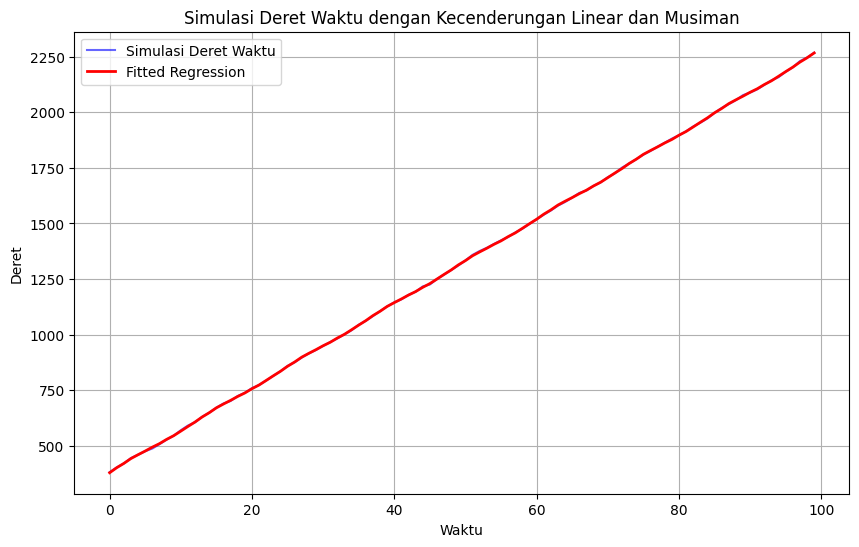

In [141]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!
Hasil: BP p=0.9796, Ljung-Box p (lag 10)=0.4486, Shapiro-Wilk p=0.1508, Durbin-Watson=1.94.
Interpretasi: Semua p-value > 0.05  tidak ada pelanggaran asumsi. Model gabungan tren+musiman ini juga sudah tepat; nilai Shapiro-Wilk yang sedikit lebih rendah (0.15) masih jauh dari batas 0.05 sehingga tetap disimpulkan residual normal.

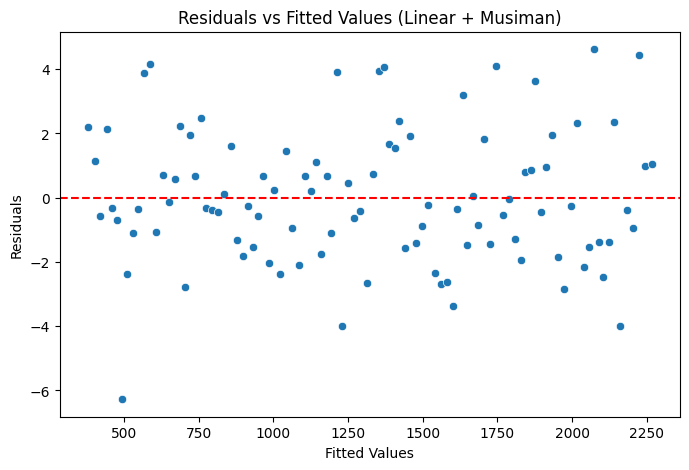

P-value Breusch-Pagan Test (Linear + Musiman): 0.6442


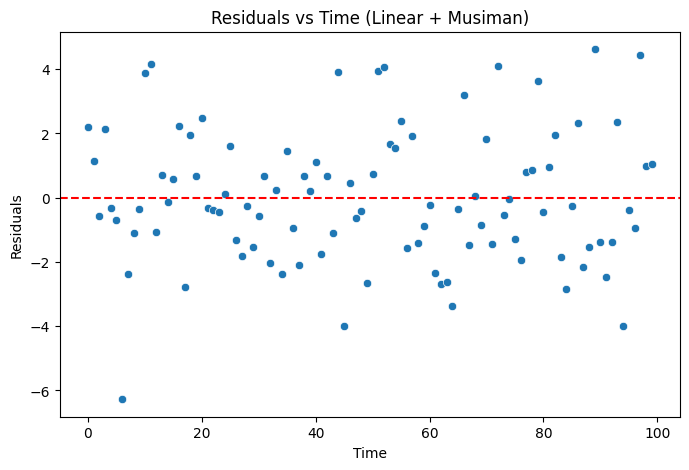

<Figure size 800x500 with 0 Axes>

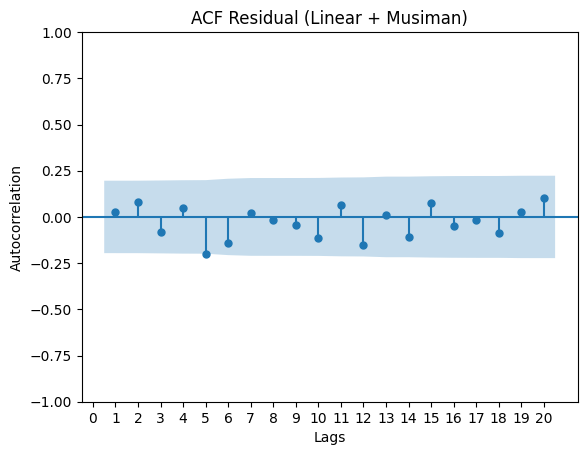

Ljung-Box Test (Linear + Musiman):
      lb_stat  lb_pvalue
1    0.063857   0.800500
2    0.697885   0.705434
3    1.410175   0.703151
4    1.665007   0.797064
5    5.977156   0.308448
6    8.193842   0.224243
7    8.240243   0.311887
8    8.266231   0.407906
9    8.487402   0.485869
10   9.908094   0.448593
11  10.425894   0.492533
12  13.074132   0.363676
13  13.087881   0.441047
14  14.447468   0.416934
15  15.135625   0.441693
16  15.406698   0.495077
17  15.447735   0.563266
18  16.348199   0.568261
19  16.430973   0.628358


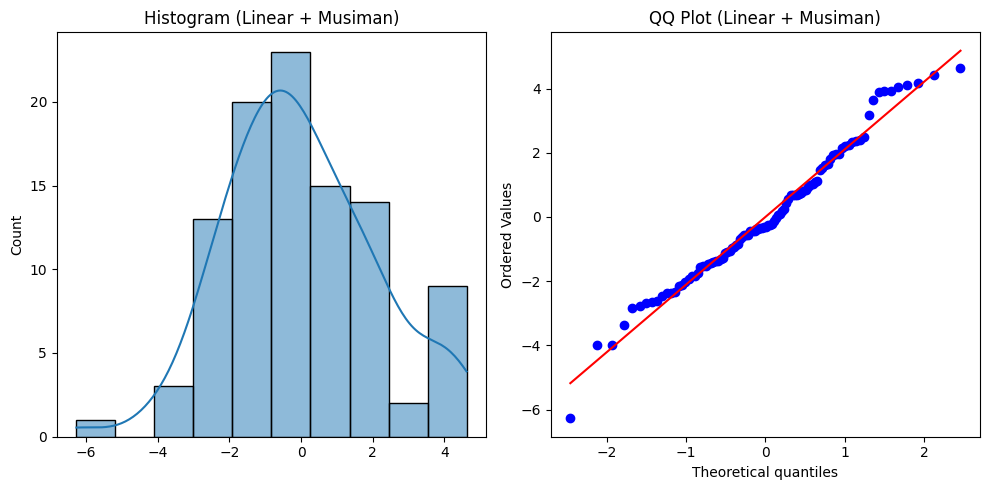

Shapiro-Wilk Test (Linear + Musiman): Statistics = 0.9807, p-value = 0.1508


In [142]:
# uji asumsi model
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
import seaborn as sns

# 1. Residual vs Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model_mix.fittedvalues, y=model_mix.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Linear + Musiman)")
plt.show()

# 2. Uji Breusch-Pagan (homoskedastisitas)
bp_test_mix = het_breuschpagan(model_mix.resid, sm.add_constant(model_mix.fittedvalues))
print(f"P-value Breusch-Pagan Test (Linear + Musiman): {bp_test_mix[1]:.4f}")

# 3. Residual vs Time
plt.figure(figsize=(8,5))
sns.scatterplot(x=x, y=model_mix.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.title("Residuals vs Time (Linear + Musiman)")
plt.show()

# 4. ACF Residual
plt.figure(figsize=(8, 5))
plot_acf(model_mix.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("ACF Residual (Linear + Musiman)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

# 5. Uji Ljung-Box
ljung_box_mix = acorr_ljungbox(model_mix.resid, lags=range(1,20), return_df=True)
print("Ljung-Box Test (Linear + Musiman):")
print(ljung_box_mix)

# 6. Histogram dan QQ-Plot
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(model_mix.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram (Linear + Musiman)')
stats.probplot(model_mix.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot (Linear + Musiman)')
plt.tight_layout()
plt.show()

# 7. Uji Shapiro-Wilk
shapiro_stat_mix, shapiro_p_mix = stats.shapiro(model_mix.resid)
print(f"Shapiro-Wilk Test (Linear + Musiman): Statistics = {shapiro_stat_mix:.4f}, p-value = {shapiro_p_mix:.4f}")


Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

Jadi, inti dari teks pengantar ini adalah: dekomposisi menjadi alat diagnostik objektif untuk mengonfirmasi keberadaan (atau ketiadaan) tren dan musiman dalam suatu deret, menggantikan tebakan visual semata yang bisa keliru terutama saat komponen-komponen tersebut bercampur dan sulit dibedakan langsung dari plot mentah.

In [143]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

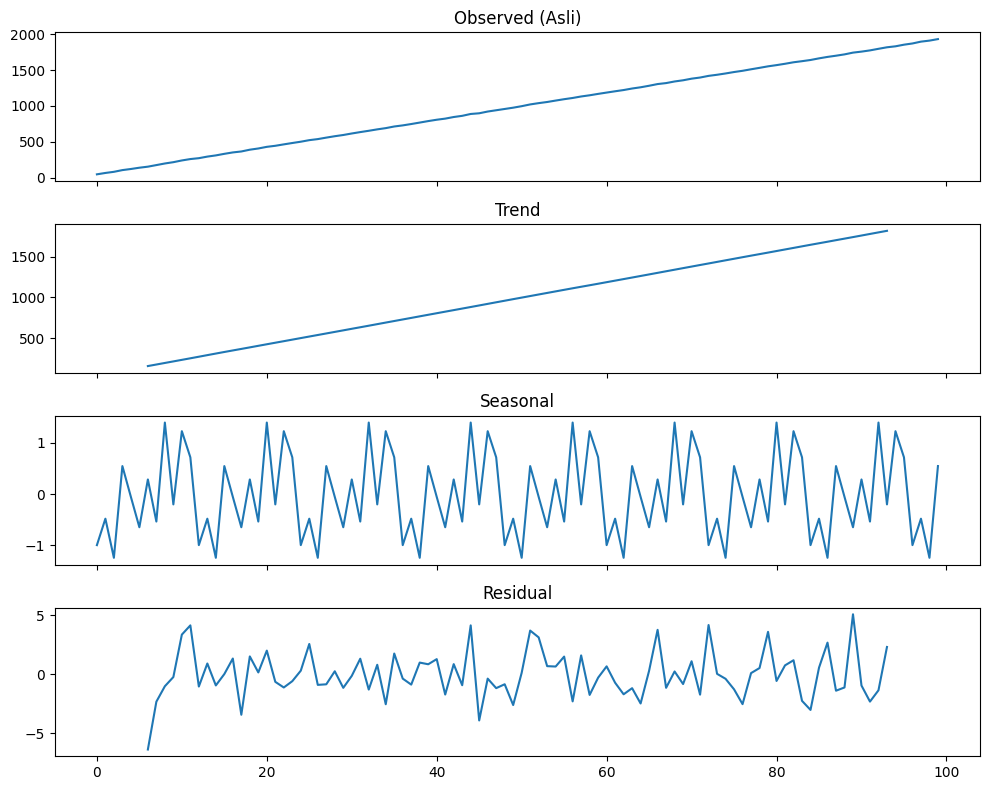

In [144]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?
Dekomposisi dilakukan pada deret linear murni Bagian 1 (β₀=48, β₁=19, tanpa musiman sungguhan), dengan period=12 dipaksakan secara arbitrer (bukan karena datanya memang musiman 12 bulan).

Trend: berupa garis naik yang halus, mengikuti pola kenaikan linear asli data dengan sangat baik (ada beberapa nilai NaN di ujung awal dan akhir, karena metode moving average butuh setengah periode data di kedua sisi untuk menghitung tren).

Seasonal: karena deret aslinya memang tidak punya pola musiman sungguhan, komponen ini seharusnya berupa fluktuasi yang sangat kecil dan berulang secara artifisial (hanya "memaksa" pola berperiode 12 pada data yang sebenarnya tidak musiman) bukan sinyal musiman yang bermakna.

Residual: berupa noise kecil acak di sekitar nol, mencerminkan komponen galat acak
𝑁
(
0
,
2
2
)
N(0,2
2
) yang memang disisipkan saat simulasi.

Kesimpulan: Dekomposisi berhasil mengenali dominasi komponen tren pada deret ini, dan dengan benar menunjukkan bahwa komponen musiman tidak substansial — mengonfirmasi bahwa deret ini murni bersifat tren linear + noise, tanpa musiman nyata.

In [145]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

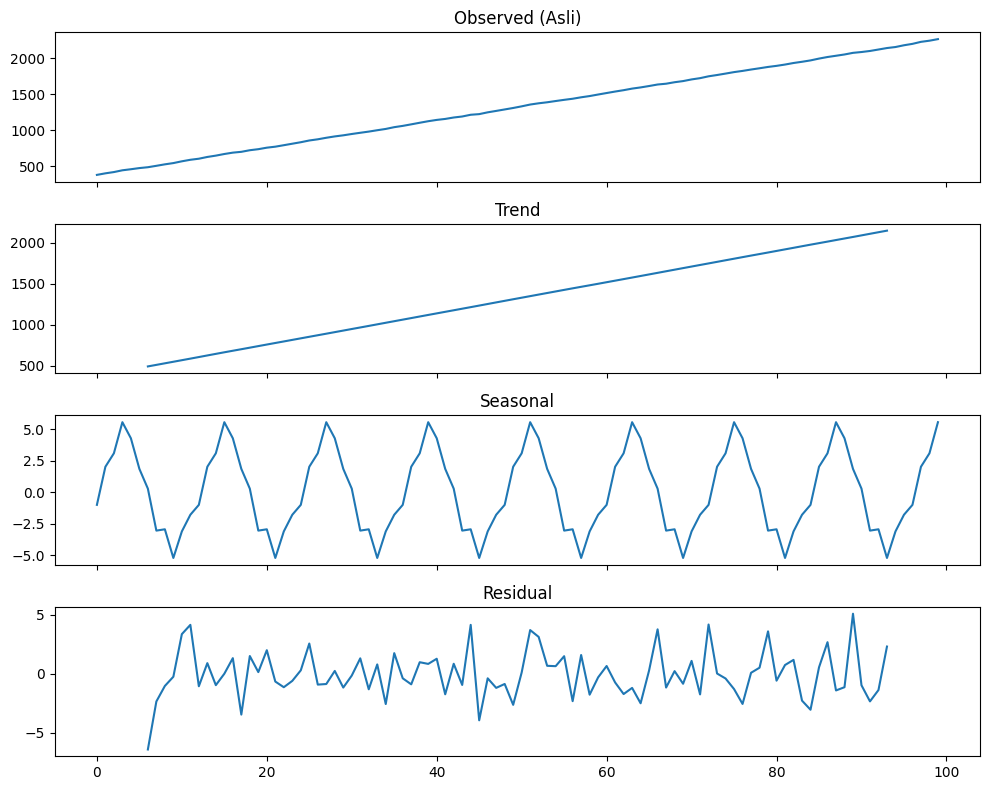

In [146]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()



Dekomposisi diterapkan pada deret gabungan Bagian 4 df_mix: tren
𝑎=19,𝑏=380 a=19,b=380 + musiman sinusoidal amplitudo 5, periode 12).

Trend: garis naik halus yang menangkap kenaikan linear dengan baik (dengan NaN di ujung-ujung deret, sama seperti sebelumnya).
Seasonal: kali ini menunjukkan pola berulang yang jelas dan teratur dengan periode 12, amplitudo berkisar ±5 — cocok dengan komponen musiman sinusoidal yang memang sengaja disisipkan dalam simulasi (Cell 58).
Residual: fluktuasi kecil acak di sekitar nol, mencerminkan noise
𝑁
(
0
,
2
2
)
N(0,2
2
).

Kesimpulan:  tren linear, musiman sinusoidal berperiode 12, dan noise acak — sesuai persis dengan desain simulasi aslinya. Ini menunjukkan seasonal_decompose bekerja dengan tepat ketika komponen musiman memang benar-benar ada dalam data.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [147]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1038)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 1.9, 380 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

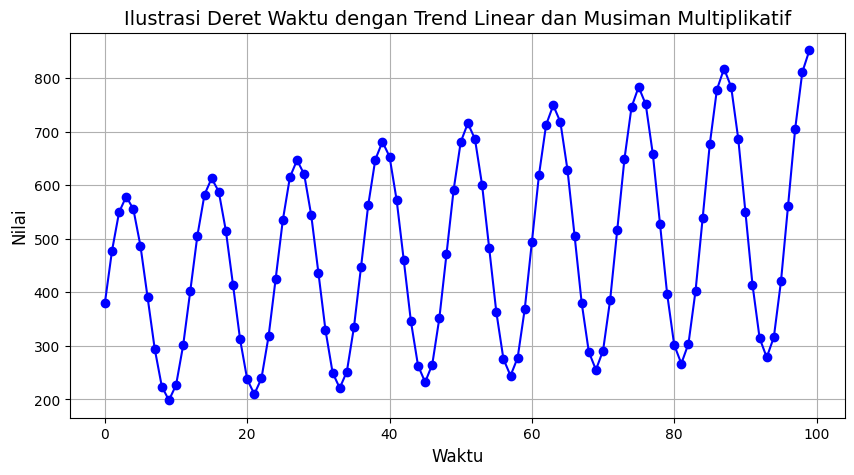

In [148]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [149]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

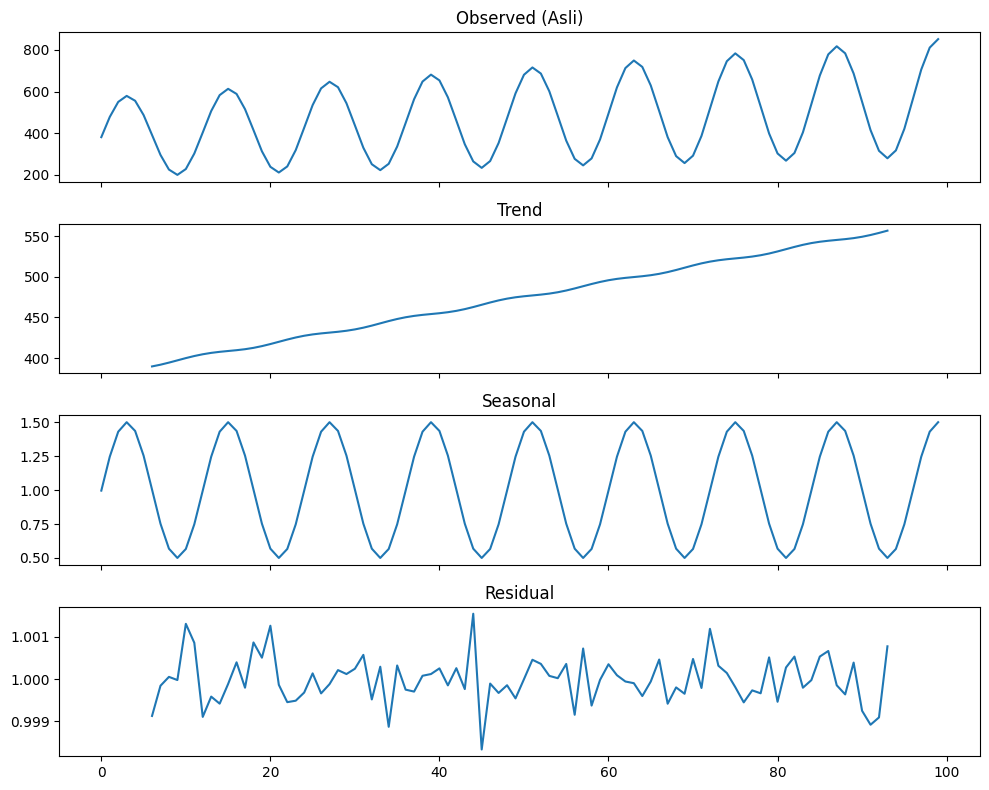

In [150]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?
Deret ini dibangun dengan trend * seasonality + noise, di mana tren =
1.9
𝑡
+
380
1.9t+380 dan musiman =
1
+
0.5
sin
⁡
(
2
𝜋
𝑡
/
12
)
1+0.5sin(2πt/12) . Karena musiman dikalikan dengan tren yang terus naik, amplitudo osilasi pada deret asli  membesar seiring waktu — ini alasan dipakainya model multiplikatif.

Trend: tetap berupa garis naik halus, mengikuti
1.9
𝑡
+
380
1.9t+380.

Seasonal di sini dinyatakan sebagai rasio (bukan nilai absolut) berosilasi di sekitar 1, dengan rentang kira-kira 0.5–1.5 — sesuai formula asli
1
+
0.5
sin
⁡
(
⋅
)
1+0.5sin(⋅). Karena berbentuk rasio, amplitudonya tetap konstan secara relatif, meskipun amplitudo absolut pada data asli terus membesar.


Residual: juga dinyatakan sebagai rasio mendekati 1 (bukan mendekati 0 seperti pada model aditif), mencerminkan noise kecil relatif terhadap level data.

Kesimpulan: Model multiplikatif memang tepat dipakai di sini, karena mampu menangkap fakta bahwa besarnya fluktuasi musiman berskala proporsional terhadap level tren (bukan konstan seperti pada kasus aditif). Jika dipaksakan model aditif pada deret ini, residualnya akan menunjukkan pola sisa yang sistematis (heteroskedastik/membesar seiring waktu).

In [151]:
# Parameter
np.random.seed(1038)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

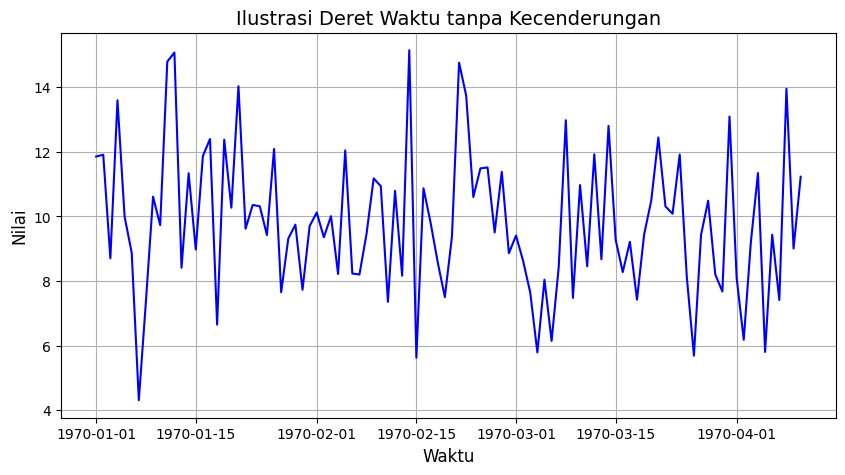

In [152]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

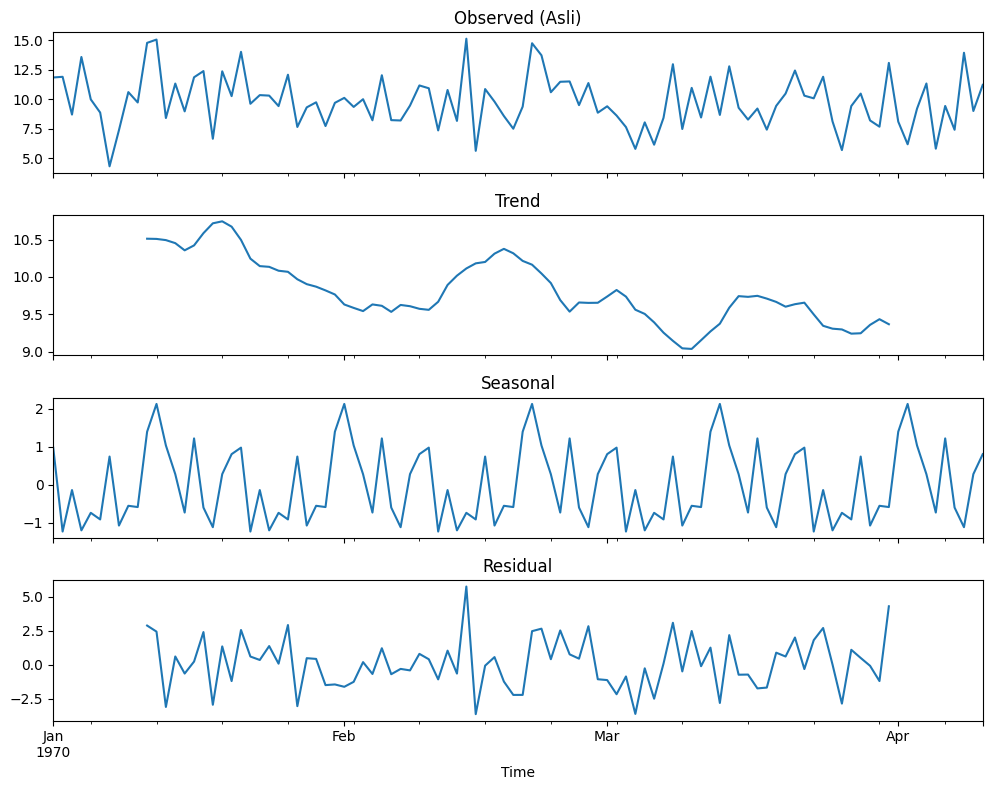

In [153]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?
Deret ini murni noise
𝑁
(
10
,
2
2
)
N(10,2
2
) tanpa tren maupun musiman sungguhan , didekomposisi dengan period=20 yang dipaksakan secara sembarang (arbitrer, karena tak ada dasar periode musiman yang sebenarnya).

Trend: mendekati garis datar di sekitar nilai 10 sesuai ekspektasi, karena memang tidak ada tren dalam data.
Seasonal: karena data sebenarnya adalah white noise, komponen musiman ini seharusnya sangat kecil dan tidak bermakna — hanya menangkap fluktuasi acak yang kebetulan tampak "berulang" dalam jendela 20 titik yang dipaksakan, bukan pola musiman sungguhan.
Residual: mendominasi hampir seluruh variasi total dalam deret — mengonfirmasi bahwa hampir semua variasi pada data ini memang berasal dari komponen acak (noise), bukan dari tren atau musiman.

Kesimpulan:
Ini adalah contoh penting yang menunjukkan bahwa dekomposisi tidak memaksakan pola tren/musiman yang tidak ada — pada data yang sebenarnya murni acak, komponen trend dan seasonal akan tampak datar/tidak substansial, sementara residual menyerap (menampung) hampir seluruh variasi data. Ini membuktikan keandalan seasonal_decompose untuk membedakan deret yang benar-benar punya struktur (tren/musiman) dari deret yang murni derau acak.